Description of the method explored in this notebook:

One other goal could be that we have a feature space in which there are only unknown objects - for example objects from alerts of one night of observation, so the feature space would change every night - and we want to know which among these are more likely to be of the positive class.

To do this, we take known objects from the positive class as inputs to the model to see what are their nearest neighbors in the feature space. If an output appears multiple times (an object that would be the neighbor of multiple inputs), we could treat it as a higher level of confidence that it is of the positive class.  
Again, the efficiency of this model relies on how well separated are objects from different classes in the feature space.

To measure the accuracy of this model, we add known objects from the positive class (different from the inputs) in the feature space and check how often they get selected by the model.

---

##### Imports & setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from magcvs_library.functions import tqdm2
import warnings
# Disabling FutureWarnings:
warnings.filterwarnings('ignore', category=FutureWarning)

# Feature names (without linear features):
feature_names = ['mean', 'weightedMean', 'std', 'median', 'amplitude', 'beyond1Std', 'cusum', 'IPR10',
                 'kurtosis', 'MPR40_5', 'MPR20_10', 'maxSlope', 'medianAbsDev', 'medianBRP10',
                 'percentAmplitude', 'meanVariance', 'andersonDarlingNorm', 'chi2', 'skew', 'stetsonK']

## Get data

In [2]:
# The following paths should be changed accordingly. The data can be saved from the features_from_light_curves.ipynb notebook.
positive = pd.read_parquet('../../data/magcvs/features_g.parquet')
negative = pd.read_parquet('../../data/negative/features_g.parquet')

# Adding labels for each class:
positive['class'] = 'positive'
negative['class'] = 'negative'

# Normalizing features:
all = pd.concat([positive, negative]) # Grouping positive & negative together so that they are then normalized the same way.
all = normalize(all[feature_names], axis=0)
positive[feature_names] = all[:len(positive)]
negative[feature_names] = all[len(positive):]

# positive_train will be in the feature space with negative objects,
# positive_test will be the input to the nearest neighbors algorithm:
positive_train, positive_test = train_test_split(positive, train_size=.7, random_state=42)

## Functions

In [3]:
def find_candidates(positive_train: pd.DataFrame, positive_test: pd.DataFrame, negative_sample: pd.DataFrame, n_neighbors=5, candidate_threshold=1):
    """
    Evaluates candidates for the positive class among given objects in the feature space (positive_train & negative_sample) using the nearest neighbors algorithm on given positive class objects (positive_test).  
    The candidates are objects that appear more than 'candidate_threshold' times in the neighbors of the positive_test objects.  
    The three inputted DataFrames should contain the same features (feature_names) and have columns 'objectId', 'time_range (yr)', 'nb_of_points', 'class'.  
    Returns the candidates in a DataFrame and the accuracy, which is defined as the proportion of candidates that are of the positie class (those that are in the positive_train DataFrame).  
    Note that the accuracy may be lower that it should be if unknown objects in the negative sample are of the positive class.

    Args:
        n_neighbors (int, optional): Number of neighbors for the nearest neighbors algorithm. Defaults to 5.
        candidate_threshold (int, optional): Parameter for candidate evaluation. Defaults to 1.

    Returns:
        :pd.DataFrame: Candidates for the positive class.  
        :float: Ratio of candidates being of the positive class.
    """

    # Building the feature space in which to find the candidates:
    feature_space = pd.concat([negative_sample, positive_train]).reset_index(drop=True)

    # Finding the nearest neighbors of positive objects:
    neigh = NearestNeighbors(n_neighbors=n_neighbors).fit(feature_space[feature_names])
    neighbors_distance, neighbors_indices = neigh.kneighbors(positive_test[feature_names])
    neighbors = feature_space.loc[neighbors_indices.flatten()]

    # Ids of the neighbors and the number of times each id appears:
    ids, counts = np.unique(neighbors['objectId'], return_counts=True)

    # Creating the DataFrame that will store the candidates:
    col = ['objectId', 'time_range (yr)', 'nb_of_points', 'class']
    candidates = pd.DataFrame(columns=[*col, 'count'])

    # Adding the candidates to the DataFrame:
    for id, count in zip(ids, counts):
        if count > candidate_threshold: # An object is considered as a candidate if it appears more than 'candidate_threshold' times in the neighbors
            candidate = neighbors[neighbors['objectId'] == id]
            new_row = pd.DataFrame([dict(zip(candidates.columns, [candidate['objectId'].values[0], candidate['time_range (yr)'].values[0], candidate['nb_of_points'].values[0], candidate['class'].values[0], count]))])
            candidates = pd.concat([candidates, new_row], ignore_index=True)

    # Computing the accuracy of candidates being of the positive class:
    positive_nb = 0
    for obj_class in candidates['class']:
        if obj_class == 'positive':
            positive_nb += 1
    if len(candidates) > 0:
        accuracy = positive_nb / len(candidates)
    else:
        accuracy = 0

    return candidates.reset_index(drop=True), accuracy

In [4]:
def candidates_mean_accuracy(N=100, negative_sample_size=30_000, n_neighbors=5, candidate_threshold=1):
    """
    Computes the mean accuracy and associated standard deviation over N candidate evaluations with a random sample of negative objects each time.

    Args:
        N (int, optional): Number of iterations for computing the mean. Defaults to 100. High impact on computation time.
        negative_sample_size (int, optional): Number of objects to be randomly sampled from the negative class at each iteration. Defaults to 30_000.
        n_neighbors (int, optional): Number of neighbors for the nearest neighbors algorithm. Defaults to 5.
        candidate_threshold (int, optional): Parameter for candidate evaluation. Defaults to 1.

    Returns:
        :float: Accuracy - Ratio of candidates being of the positive class.
        :float: Standard deviation of the accuracy.
    """
    
    accuracies = []
    for _ in range(N):
        negative_sample = negative.sample(n=negative_sample_size)
        candidates, accuracy = find_candidates(positive_train, positive_test, negative_sample, n_neighbors=n_neighbors, candidate_threshold=candidate_threshold)
        accuracies.append(accuracy)
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    
    return mean_accuracy, std_accuracy

In [5]:
def acc_vs_n_neigh(negative_sample_size=30_000, candidate_threshold=1, n_neighbors_list=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20], N=100):
    """
    Function to evaluate and plot the mean accuracy as a function of the number of neighbors and other parameters.
    Args:
        negative_sample_size (_type_, optional): Number of objects to be randomly sampled from the negative class at each iteration. Defaults to 30_000.
        candidate_threshold (int, optional): Parameter for candidate evaluation. Defaults to 1.
        n_neighbors_list (list, optional): List of number of nearest neighbors (x-axis). Defaults to [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20].
        N (int, optional): Number of iterations for computing the mean. Defaults to 100. High impact on computation time.
    """
    
    # Computing the mean accuracy for each number of neighbors:
    mean_accuracies = []
    for n_neighbors in tqdm2(n_neighbors_list):
        mean_accuracy, std_accuracy = candidates_mean_accuracy(N=N, negative_sample_size=negative_sample_size, n_neighbors=n_neighbors, candidate_threshold=candidate_threshold)
        mean_accuracies.append((mean_accuracy, std_accuracy))

    # Plot:
    plt.errorbar(n_neighbors_list, [mean_accuracy[0]*100 for mean_accuracy in mean_accuracies], yerr=[mean_accuracy[1]*100 for mean_accuracy in mean_accuracies], fmt='o')
    plt.title(f'Mean accuracy versus number of neighbors\n{negative_sample_size} negative objects in the feature space, candidate threshold = {candidate_threshold}')
    plt.xlabel('Number of neighbors')
    plt.ylabel('Mean accuracy (%)')
    plt.xticks(n_neighbors_list)
    plt.ylim(0, 100)
    plt.grid(axis='x')
    plt.axhline(y=50, color='r', linestyle='--', label='50% accuracy')
    plt.legend(loc='upper right')
    plt.tight_layout()

## Plots

### Varying the number of objects sampled from the negative class:

100%|██████████| 16/16


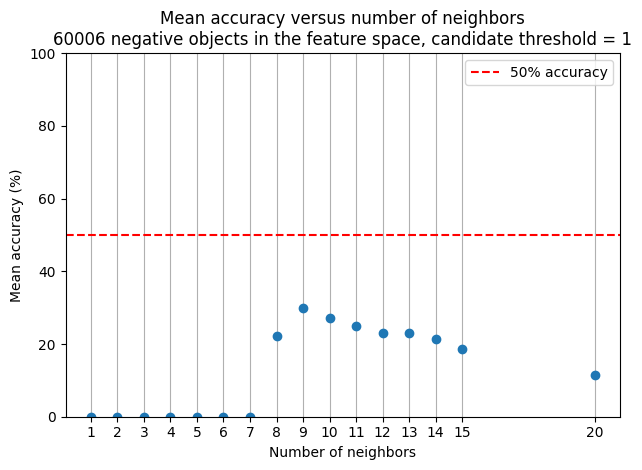

In [6]:
# With all objects from the negative class:
acc_vs_n_neigh(negative_sample_size=len(negative), N=1)

100%|██████████| 16/16


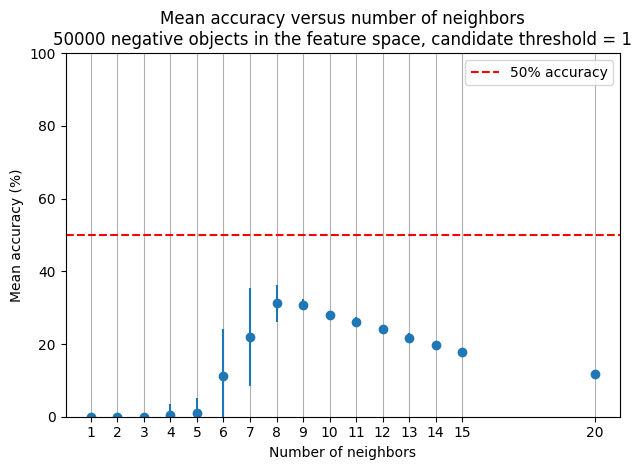

In [7]:
acc_vs_n_neigh(negative_sample_size=50_000)

100%|██████████| 16/16


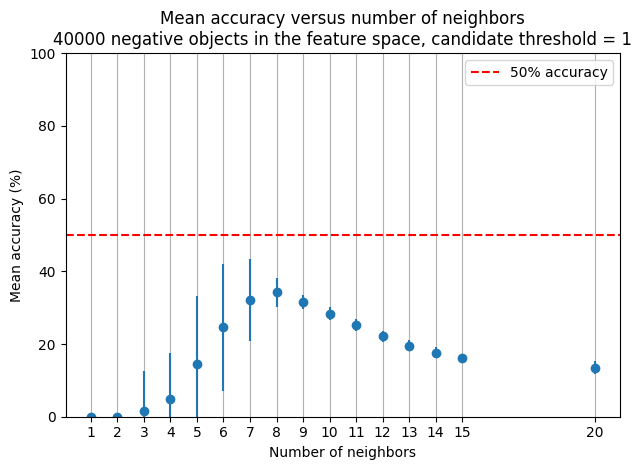

In [8]:
acc_vs_n_neigh(negative_sample_size=40_000)

100%|██████████| 16/16


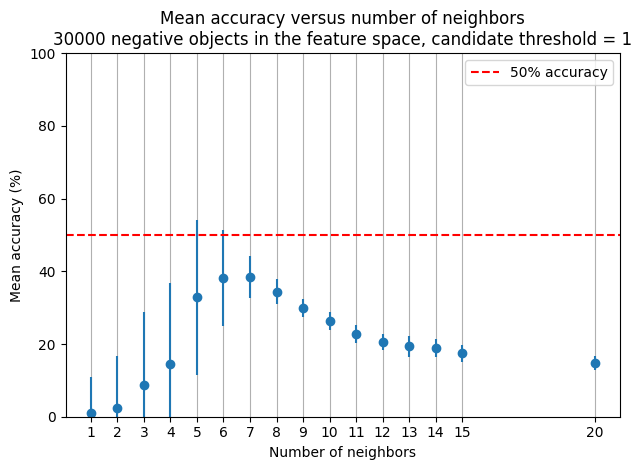

In [9]:
acc_vs_n_neigh(negative_sample_size=30_000)

100%|██████████| 16/16


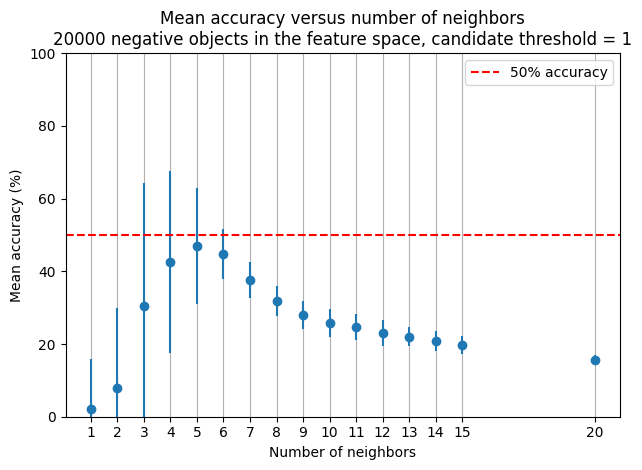

In [10]:
acc_vs_n_neigh(negative_sample_size=20_000)

100%|██████████| 16/16


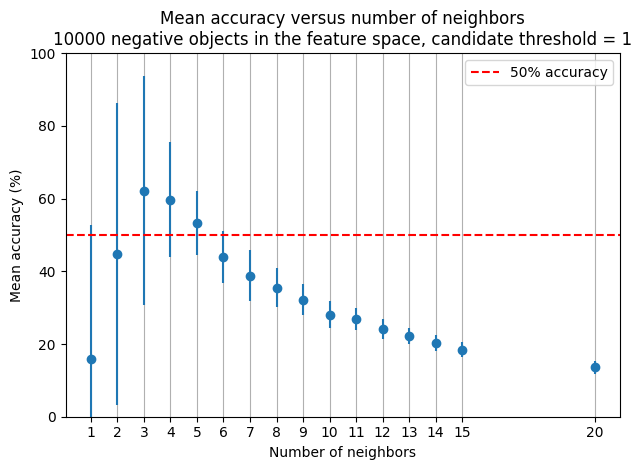

In [11]:
acc_vs_n_neigh(negative_sample_size=10_000)

### Varying the candidate threshold:

100%|██████████| 16/16


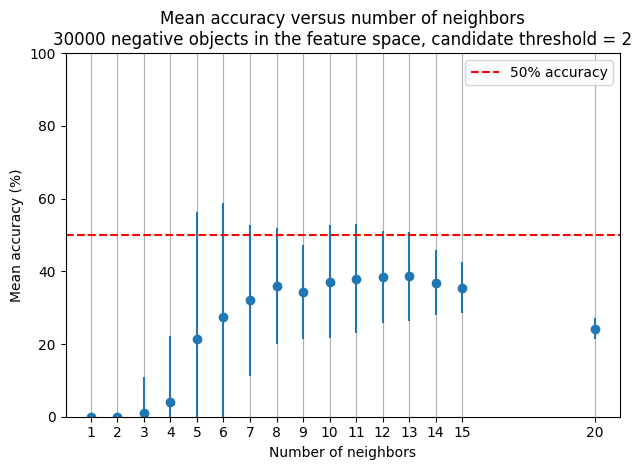

In [12]:
acc_vs_n_neigh(candidate_threshold=2)

100%|██████████| 8/8


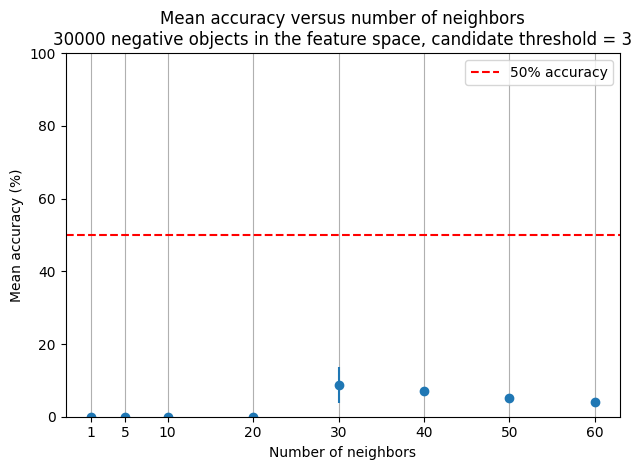

In [13]:
acc_vs_n_neigh(candidate_threshold=3, n_neighbors_list=[1, 5, 10, 20, 30, 40, 50, 60])